# Motorcycle Price Prediction

Training a regression model to predict used motorcycle prices based on brand, year, mileage, and ownership history.

Dataset: [Kaggle - Motorcycle Dataset](https://www.kaggle.com/datasets/nehalbirla/motorcycle-dataset)

## 1. Upload Dataset

In [11]:
from google.colab import files
uploaded = files.upload()


Saving BIKE DETAILS.csv to BIKE DETAILS (2).csv


## 2. Load and Inspect Data

Load the CSV file and check the structure, missing values, and basic statistics.

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("BIKE DETAILS.csv")
print(df.head())
print(f"\nTotal entries: {len(df)}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nPrice statistics:\n{df['selling_price'].describe()}")

                                  name  selling_price  year seller_type  \
0            Royal Enfield Classic 350         175000  2019  Individual   
1                            Honda Dio          45000  2017  Individual   
2  Royal Enfield Classic Gunmetal Grey         150000  2018  Individual   
3    Yamaha Fazer FI V 2.0 [2016-2018]          65000  2015  Individual   
4                Yamaha SZ [2013-2014]          20000  2011  Individual   

       owner  km_driven  ex_showroom_price  
0  1st owner        350                NaN  
1  1st owner       5650                NaN  
2  1st owner      12000           148114.0  
3  1st owner      23000            89643.0  
4  2nd owner      21000                NaN  

Total entries: 1061

Columns: ['name', 'selling_price', 'year', 'seller_type', 'owner', 'km_driven', 'ex_showroom_price']

Missing values:
name                   0
selling_price          0
year                   0
seller_type            0
owner                  0
km_driven     

## 3. Exploratory Data Analysis (EDA)

Visualize price distribution, brand frequency, and relationships between price and key features.

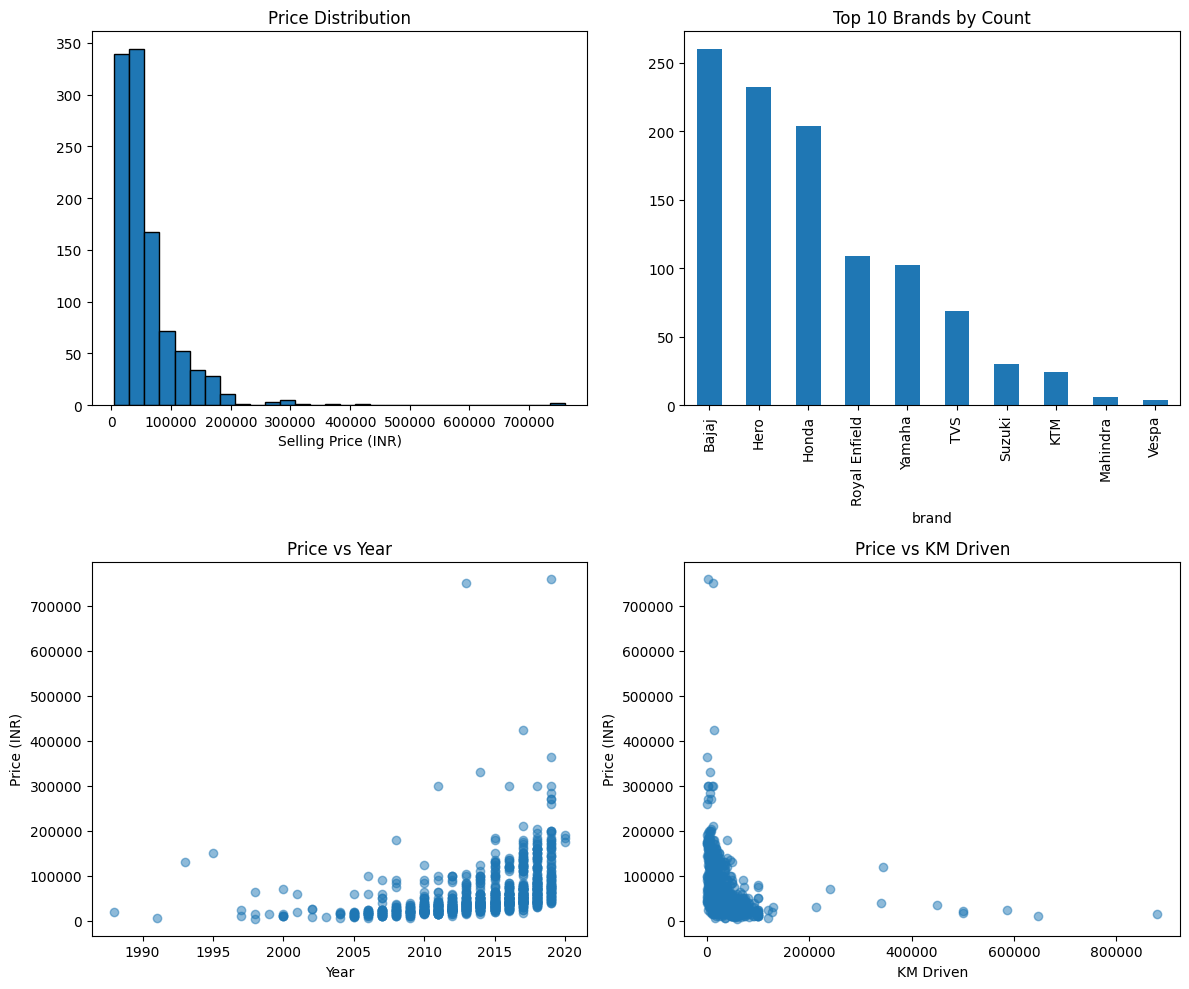


Key Findings:
- Median price: 45000 INR
- Most common brand: Bajaj (260 entries)
- Year range: 1988 - 2020
- KM range: 350 - 880000


In [13]:
import matplotlib.pyplot as plt

# Extract brand from name
df['brand'] = df['name'].apply(lambda x: x.split()[0])
df.loc[df['name'].str.startswith('Royal Enfield'), 'brand'] = 'Royal Enfield'
df.loc[df['name'].str.startswith('Harley-Davidson'), 'brand'] = 'Harley-Davidson'

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].hist(df['selling_price'], bins=30, edgecolor='black')
axes[0,0].set_title('Price Distribution')
axes[0,0].set_xlabel('Selling Price (INR)')

df['brand'].value_counts().head(10).plot(kind='bar', ax=axes[0,1])
axes[0,1].set_title('Top 10 Brands by Count')

axes[1,0].scatter(df['year'], df['selling_price'], alpha=0.5)
axes[1,0].set_title('Price vs Year')
axes[1,0].set_xlabel('Year')
axes[1,0].set_ylabel('Price (INR)')

axes[1,1].scatter(df['km_driven'], df['selling_price'], alpha=0.5)
axes[1,1].set_title('Price vs KM Driven')
axes[1,1].set_xlabel('KM Driven')
axes[1,1].set_ylabel('Price (INR)')

plt.tight_layout()
plt.show()

print("\nKey Findings:")
print(f"- Median price: {df['selling_price'].median():.0f} INR")
print(f"- Most common brand: {df['brand'].value_counts().index[0]} ({df['brand'].value_counts().values[0]} entries)")
print(f"- Year range: {df['year'].min()} - {df['year'].max()}")
print(f"- KM range: {df['km_driven'].min()} - {df['km_driven'].max()}")

## 3.1 EDA Key Findings

- **Price distribution:** Most motorcycles are priced between 20,000 and 80,000 INR. The distribution is right-skewed with a few high-value outliers above 300,000 INR.
- **Brand frequency:** Bajaj, Hero, and Honda dominate the dataset with over 200 entries each. Premium brands like BMW, Harley-Davidson, and Kawasaki have very few entries (1-4 each), which limits prediction accuracy for these brands.
- **Price vs Year:** Newer motorcycles (2018-2020) tend to have higher prices. There is a clear positive correlation between year and selling price.
- **Price vs KM:** Most motorcycles have less than 40,000 km. There is no strong visible correlation between kilometers and price, suggesting that other factors (brand, age) are more important for price.
- **Anomalies:** The `ex_showroom_price` column has 41% missing values and was excluded from modeling. Some entries have very low km values (under 500) which may indicate data entry errors or nearly-new vehicles.

## 4. Preprocessing and Feature Engineering

Encode categorical features, calculate derived features, and prepare the data for training.

In [14]:
from sklearn.model_selection import train_test_split

# Encode owner as numeric
owner_map = {
    '1st owner': 1,
    '2nd owner': 2,
    '3rd owner': 3,
    '4th owner': 4,
    '5th owner': 5
}
df['owner_num'] = df['owner'].map(owner_map).fillna(3)

# Calculate age
df['age'] = 2024 - df['year']

# Encode brand as integer
brand_codes = {brand: i for i, brand in enumerate(sorted(df['brand'].unique()))}
df['brand_code'] = df['brand'].map(brand_codes)
print(f"Brand codes: {brand_codes}")

# Define features and target
features = ['brand_code', 'year', 'km_driven', 'owner_num', 'age']
X = df[features]
y = df['selling_price']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTraining set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")

Brand codes: {'Activa': 0, 'Aprilia': 1, 'BMW': 2, 'Bajaj': 3, 'Benelli': 4, 'Harley-Davidson': 5, 'Hero': 6, 'Honda': 7, 'Hyosung': 8, 'Jawa': 9, 'KTM': 10, 'Kawasaki': 11, 'Mahindra': 12, 'Royal Enfield': 13, 'Suzuki': 14, 'TVS': 15, 'UM': 16, 'Vespa': 17, 'Yamaha': 18, 'Yo': 19}

Training set: 848 samples
Test set: 213 samples


## 5. Model Training and Comparison

Train two different models (Random Forest and Gradient Boosting) and compare their performance.

In [15]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Model 1: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest:")
print(f"  MAE: {rf_mae:.0f}")
print(f"  R2:  {rf_r2:.4f}")

# Model 2: Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_r2 = r2_score(y_test, gb_pred)

print("\nGradient Boosting:")
print(f"  MAE: {gb_mae:.0f}")
print(f"  R2:  {gb_r2:.4f}")

# Select best model
if gb_r2 > rf_r2:
    best_model = gb
    best_name = "Gradient Boosting"
else:
    best_model = rf
    best_name = "Random Forest"
print(f"\nBest model: {best_name}")

Random Forest:
  MAE: 19135
  R2:  0.5511

Gradient Boosting:
  MAE: 17764
  R2:  0.6335

Best model: Gradient Boosting


## 6. Save Model

Save the best performing model and the brand encoding for use in the deployed application.

In [16]:
import pickle

with open("motorcycle_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("brand_codes.pkl", "wb") as f:
    pickle.dump(brand_codes, f)

print("Model saved: motorcycle_price_model.pkl")
print(f"Brand codes saved: {brand_codes}")

Model saved: motorcycle_price_model.pkl
Brand codes saved: {'Activa': 0, 'Aprilia': 1, 'BMW': 2, 'Bajaj': 3, 'Benelli': 4, 'Harley-Davidson': 5, 'Hero': 6, 'Honda': 7, 'Hyosung': 8, 'Jawa': 9, 'KTM': 10, 'Kawasaki': 11, 'Mahindra': 12, 'Royal Enfield': 13, 'Suzuki': 14, 'TVS': 15, 'UM': 16, 'Vespa': 17, 'Yamaha': 18, 'Yo': 19}


## 7. Download Files

Download the trained model and brand codes for deployment.

In [17]:
from google.colab import files
files.download("motorcycle_price_model.pkl")
files.download("brand_codes.pkl")
print("Files downloaded.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Files downloaded.
